Aritmitic Agent 

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.prebuilt import ToolNode , tools_condition
from langchain.messages import HumanMessage
from langgraph.graph import START , StateGraph , END , MessagesState 
from IPython.display import display , Image
from pprint import pprint
from dotenv import load_dotenv

load_dotenv()


True

In [2]:
llm = ChatGoogleGenerativeAI(
    model = 'gemini-3-flash-preview'
)

Tool for agent 


In [3]:
def multiply(a:int , b:int) -> int:
    """Multiply a and b 
    
    Keyword arguments:
    a -- number 1
    b -- number 2 
    Return: result after multipling 
    """
    return a*b

def add(a:int , b:int) -> int :
    """Add a and b 
    
    Keyword arguments:
    a -- number 1
    b -- number 2
    Return: result after adding 
    """
    return a+b 

    



Bind the tools with the llm 

In [4]:
llm_with_tools = llm.bind_tools([multiply , add])

State for the graph 

In [9]:
class State(MessagesState):
    pass

Tool calling Llm  function


In [10]:
def tools_calling_llm(state : State):
    return {
        'messages' : llm_with_tools.invoke(state['messages'])
    }

Build the agent 


In [16]:
builder = StateGraph(State)
builder.add_node("tools_calling_llm" , tools_calling_llm)

builder.add_edge(START , "tools_calling_llm")
builder.add_node('tools' , ToolNode([multiply , add]))
builder.add_conditional_edges(
    "tools_calling_llm" , 
    tools_condition
)
builder.add_edge('tools' , "tools_calling_llm")
builder.add_edge("tools_calling_llm" , END)

In [17]:
agent = builder.compile()

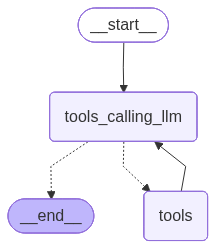

In [18]:
agent

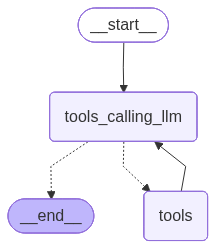

In [21]:
display(Image(agent.get_graph().draw_mermaid_png()))

In [24]:
result = agent.invoke(
    {
        "messages" : HumanMessage("What is 10 add by 2 multiplyed by 2" , name="puvith")
    }
)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [25]:
result

{'messages': [HumanMessage(content='What is 10 add by 2 multiplyed by 2', additional_kwargs={}, response_metadata={}, name='puvith', id='75de893c-890b-4e5b-a890-790dcb89492e'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"b": 2, "a": 2}'}, '__gemini_function_call_thought_signatures__': {'31ca806a-5120-4d42-97d2-d56d4533f587': 'EpUKCpIKAQw51sfpd/XT22hOkqHBrst9v/p9gDRtLEsDUlS2eEbflV+uMXgZNuVVdbKASmm0RKaoUgiknCLCYP99/LM9Wj2EUS0cg3XnLC80F07feqbR5fa1Tbc0g9+aTfHyd7WgFIjEAW7QJJ1G0N6v0D6fB8DR2Ja44JMWhl1b2W4Mh4E8kugeXRLew7NjT0tlkxj0u6ktJkgLFb2/kgmtTDMbRaASvODVAupY4SsiMN9aIXKE9TJeC4il/KP6IELZqb5Lly7JR/NPBQ8i+fTQ23cK+R10qbpFLNLWXtuUhO7m4g2kR7maj8O1C9CLrcUETHKYyZKyMrgbFRn1ULKHABVcTZJb5UDrY3S6SAqyzBkeutfIqJFA26fXYQcyHcE30GqHQEOfGgYZ+GlcWApbGV04ajOMMXoLLrewSfeCZviDlV3o+4L6BI8p+GHB6CTLknd+q1app6ZlBOc58TtST+LGiVU0zDIaYdowWShj8EHSuCiXY57SCA1L/UBfEMOHdVlrq8lyXjYV9yNzCrdeNqnPHyReu0fYMiVglggUKShl+KwuCEXe/eDFa4J7/CaatS43DqEdRsi/IqTpeunEpAoz9Awxp4IYgJ9Nk1L

In [27]:
for i in result["messages"]:
    i.pretty_print()

================================ Human Message =================================
Name: puvith

What is 10 add by 2 multiplyed by 2
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (31ca806a-5120-4d42-97d2-d56d4533f587)
 Call ID: 31ca806a-5120-4d42-97d2-d56d4533f587
  Args:
    b: 2
    a: 2
================================= Tool Message =================================
Name: multiply

4
================================== Ai Message ==================================

[]
Tool Calls:
  add (636fb224-511c-477a-b867-e29d72db3de4)
 Call ID: 636fb224-511c-477a-b867-e29d72db3de4
  Args:
    b: 4
    a: 10
================================= Tool Message =================================
Name: add

14
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Following the standard mathematical order of operations (multiplication before addition), 10 + 2 × 2 is **14**.\n\nHere is the bre